In [1]:
import os
import numpy as np
import pandas as pd
import scipy.io as sio
import scipy.signal as sig
import tensorflow as tf
import pywt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split ,StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense, Dropout, GlobalAveragePooling1D, LSTM
from tensorflow.keras.models import Sequential
from sklearn.utils import shuffle
import matplotlib.pyplot as plt

In [2]:
# Function to apply data augmentation to each record segment
def augment_signal(signal):
    shift = np.random.randint(-100, 100)  # Time shifting between -100 to +100 samples
    augmented_signal = np.roll(signal, shift).astype(np.float64)

    scale_factor = np.random.uniform(0.8, 1.2)  # Amplitude scaling between 0.8 to 1.2
    augmented_signal *= scale_factor

    noise = np.random.normal(0, 0.05, size=len(signal))  # Gaussian noise injection
    augmented_signal += noise.astype(np.float64)

    return augmented_signal

In [3]:
# Function to denoise the signal using wavelet transform
def denoise_signal(signal, wavelet='db6', level=2):
    coeff = pywt.wavedec(signal, wavelet, mode="per")
    sigma = (1/0.6745) * np.median(np.abs(coeff[-level] - np.median(coeff[-level])))
    uthresh = sigma * np.sqrt(2*np.log(len(signal)))
    coeff[1:] = (pywt.threshold(i, value=uthresh, mode='soft') for i in coeff[1:])
    reconstructed_signal = pywt.waverec(coeff, wavelet, mode='per')
    return reconstructed_signal

In [4]:
# Function to apply bandpass filter to the signal
def bandpass_filter(signal, lowcut, highcut, fs, order=4):  
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = sig.butter(order, [low, high], btype='band')
    y = sig.filtfilt(b, a, signal) 
    return y

In [5]:
# Function to process each record
def process_record(record_name, data_dir, reference_df):
    mat_file = os.path.join(data_dir, record_name + '.mat')
    mat_data = sio.loadmat(mat_file)
    signal = mat_data['val'].squeeze()

    filtered_signal = bandpass_filter(signal, lowcut=0.1, highcut=45, fs=300)
    augmented_signal = augment_signal(filtered_signal)
    denoised_signal = denoise_signal(augmented_signal)

    signal_mean = np.mean(denoised_signal)
    signal_std = np.std(denoised_signal)
    normalized_signal = (denoised_signal - signal_mean) / signal_std

    segment_length = 20 * 300  # 20 seconds * 300 samples/second
    num_segments = len(normalized_signal) // segment_length
    segments = [normalized_signal[i * segment_length:(i + 1) * segment_length] for i in range(num_segments)]

    return segments

In [6]:
# Load reference data
reference_df = pd.read_csv('REFERENCE-v3.csv')
data_dir = 'training2017'

In [7]:
# Rename the columns in the csv file
reference_df.columns = ["records", "labels"]

In [8]:
# Process the signals from the dataset
training_segments = []
labels = []
for index, row in reference_df.iterrows():
    record_name = row['records']
    segments = process_record(record_name, data_dir, reference_df)
    label = row['labels']
    labels.extend([label] * len(segments))
    training_segments.extend(segments)

X = np.array(training_segments)
X = np.expand_dims(X, axis=-1)

In [9]:
# Encode the labels and split it into training and test sets
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(labels)
X, y = shuffle(X, y, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

C:\Users\user\AppData\Local\Temp\ipykernel_26916\1787447496.py:18: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


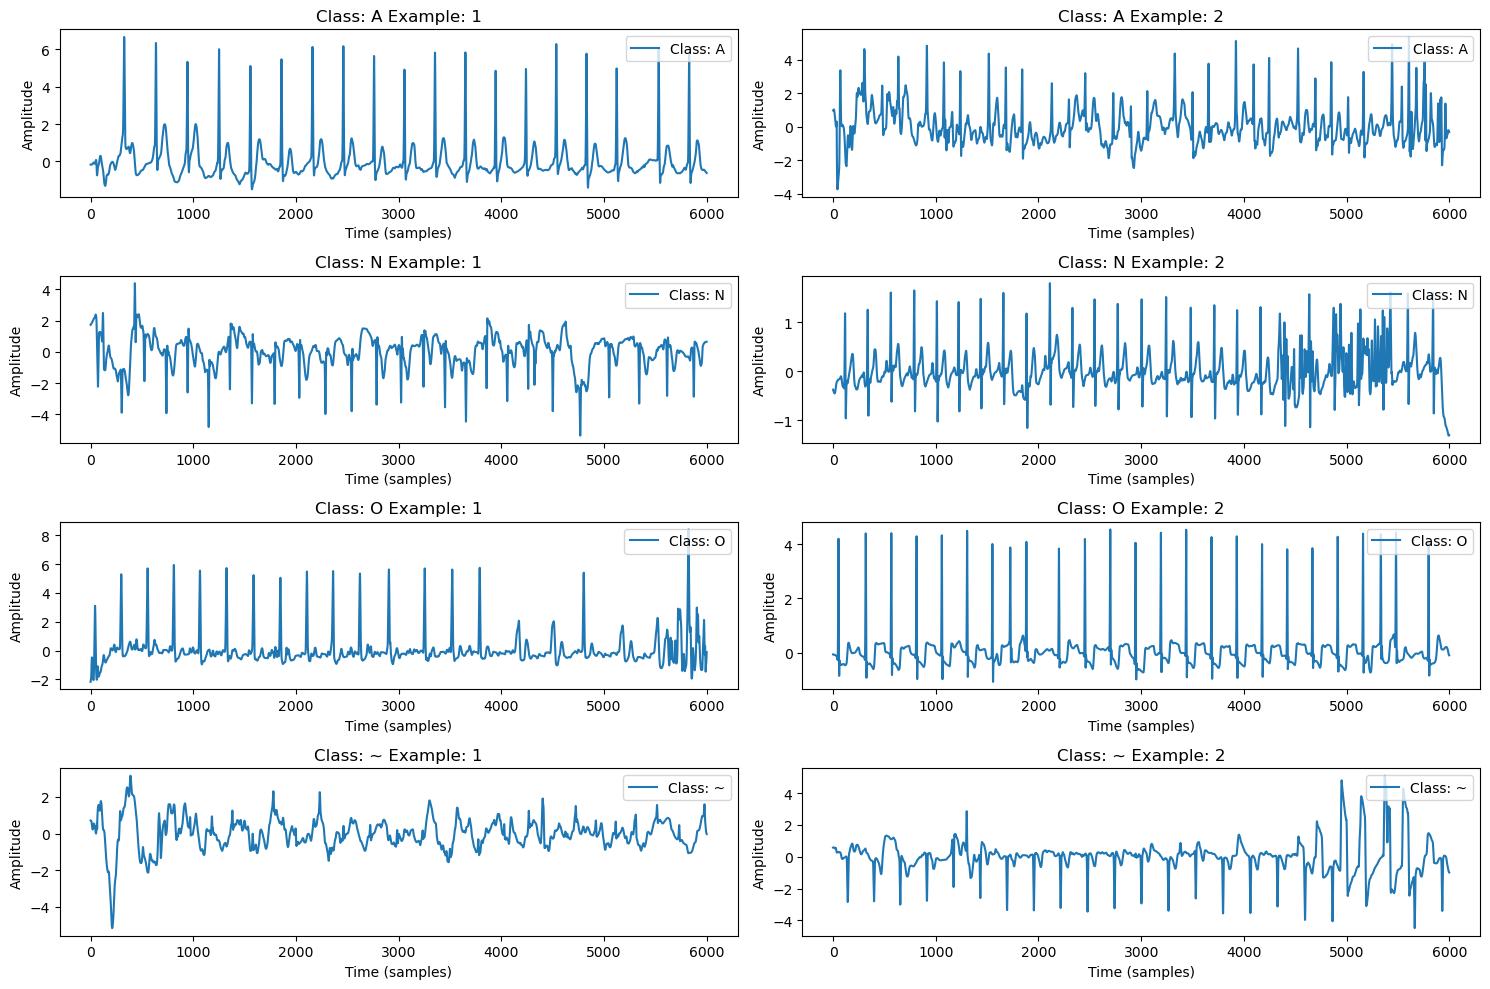

In [10]:
def plot_signal_per_class(X, y, label_encoder, num_examples=1):
    # Get unique classes
    unique_classes = np.unique(y)
    # Reverse mapping of labels to class names
    reverse_label_mapping = {index: label for index, label in enumerate(label_encoder.classes_)}
    
    plt.figure(figsize=(15, 10))
    for i, class_label in enumerate(unique_classes):
        indices = np.where(y == class_label)[0]
        for j in range(min(num_examples, len(indices))):
            index = indices[j]
            plt.subplot(len(unique_classes), num_examples, i * num_examples + j + 1)
            plt.plot(X[index].squeeze(), label=f'Class: {reverse_label_mapping[class_label]}')
            plt.legend(loc='upper right')
            plt.title(f'Class: {reverse_label_mapping[class_label]} Example: {j+1}')
            plt.xlabel('Time (samples)')
            plt.ylabel('Amplitude')
            plt.tight_layout()
    
    plt.show()

# Call the function to plot a signal from each class
plot_signal_per_class(X_train, y_train, label_encoder, num_examples=2)



In [11]:
# Perform k-fold cross-validation, build and evaluate the model 
num_folds = 10
skf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

train_accuracies, val_accuracies, test_accuracies = [], [], []

# Define early stopping callback
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

for fold, (train_index, val_index) in enumerate(skf.split(X, y)):
    print(f"Fold {fold + 1}/{num_folds}")
    X_train, X_val = X[train_index], X[val_index]
    y_train, y_val = y[train_index], y[val_index]

    # Build the model
    model = tf.keras.Sequential([
        tf.keras.layers.Conv1D(filters=8, kernel_size=5, padding='same', activation='relu', input_shape=(X_train.shape[1], 1)),
        tf.keras.layers.MaxPooling1D(pool_size=2),
        tf.keras.layers.Conv1D(filters=16, kernel_size=5, padding='same', activation='relu'),
        tf.keras.layers.MaxPooling1D(pool_size=2),
        tf.keras.layers.Conv1D(filters=32, kernel_size=5, padding='same', activation='relu'),
        tf.keras.layers.MaxPooling1D(pool_size=2),
        tf.keras.layers.Conv1D(filters=64, kernel_size=5, padding='same', activation='relu'),
        tf.keras.layers.MaxPooling1D(pool_size=2),
        tf.keras.layers.Conv1D(filters=128, kernel_size=5, padding='same', activation='relu'),
        tf.keras.layers.MaxPooling1D(pool_size=2),
        tf.keras.layers.Conv1D(filters=256, kernel_size=5, padding='same', activation='relu'),
        tf.keras.layers.MaxPooling1D(pool_size=2),
        tf.keras.layers.Conv1D(filters=512, kernel_size=5, padding='same', activation='relu'),
        tf.keras.layers.MaxPooling1D(pool_size=2),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Reshape((-1, 128)),
        tf.keras.layers.LSTM(128, return_sequences=False),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(4, activation='softmax')
    ])
    
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=64,
        verbose=1,
    )
    
    train_accuracy = model.evaluate(X_train, y_train, verbose=0)[1]
    val_accuracy = model.evaluate(X_val, y_val, verbose=0)[1]
    test_accuracy = model.evaluate(X_test, y_test, verbose=0)[1]
    
    print(f"Training Accuracy: {train_accuracy}, Validation Accuracy: {val_accuracy}, Test Accuracy: {test_accuracy}")

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)
    test_accuracies.append(test_accuracy)


Fold 1/10
Epoch 1/50


C:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


140/140 ━━━━━━━━━━━━━━━━━━━━ 19s 122ms/step - accuracy: 0.5552 - loss: 1.0256 - val_accuracy: 0.6212 - val_loss: 0.8581
Epoch 2/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 17s 123ms/step - accuracy: 0.6508 - loss: 0.8323 - val_accuracy: 0.7121 - val_loss: 0.6827
Epoch 3/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 17s 124ms/step - accuracy: 0.7132 - loss: 0.7123 - val_accuracy: 0.6485 - val_loss: 0.7158
Epoch 4/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 17s 124ms/step - accuracy: 0.7480 - loss: 0.6453 - val_accuracy: 0.7545 - val_loss: 0.5889
Epoch 5/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 17s 125ms/step - accuracy: 0.7734 - loss: 0.5978 - val_accuracy: 0.7808 - val_loss: 0.5773
Epoch 6/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 19s 134ms/step - accuracy: 0.7918 - loss: 0.5458 - val_accuracy: 0.7818 - val_loss: 0.5367
Epoch 7/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 17s 124ms/step - accuracy: 0.8095 - loss: 0.5009 - val_accuracy: 0.8051 - val_loss: 0.5155
Epoch 8/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 17s 123ms/step - accuracy: 0.8188 - loss: 0.4836 - val

140/140 ━━━━━━━━━━━━━━━━━━━━ 17s 123ms/step - accuracy: 0.9716 - loss: 0.0807 - val_accuracy: 0.8091 - val_loss: 0.9747
Epoch 49/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 18s 125ms/step - accuracy: 0.9751 - loss: 0.0660 - val_accuracy: 0.8121 - val_loss: 0.9167
Epoch 50/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 17s 124ms/step - accuracy: 0.9791 - loss: 0.0596 - val_accuracy: 0.8141 - val_loss: 0.9546
Training Accuracy: 0.9905650019645691, Validation Accuracy: 0.8141413927078247, Test Accuracy: 0.9752399921417236
Fold 3/10
Epoch 1/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 124ms/step - accuracy: 0.5362 - loss: 1.0226 - val_accuracy: 0.6232 - val_loss: 0.8586
Epoch 2/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 17s 123ms/step - accuracy: 0.6519 - loss: 0.8199 - val_accuracy: 0.7111 - val_loss: 0.7048
Epoch 3/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 17s 123ms/step - accuracy: 0.7305 - loss: 0.6799 - val_accuracy: 0.7354 - val_loss: 0.6830
Epoch 4/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 17s 124ms/step - accuracy: 0.7556 - loss: 0.6236 - val_accu

140/140 ━━━━━━━━━━━━━━━━━━━━ 17s 122ms/step - accuracy: 0.9711 - loss: 0.0852 - val_accuracy: 0.8362 - val_loss: 0.8414
Epoch 45/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 17s 122ms/step - accuracy: 0.9751 - loss: 0.0706 - val_accuracy: 0.8402 - val_loss: 0.8371
Epoch 46/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 17s 122ms/step - accuracy: 0.9624 - loss: 0.1139 - val_accuracy: 0.8352 - val_loss: 0.7093
Epoch 47/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 17s 122ms/step - accuracy: 0.9777 - loss: 0.0683 - val_accuracy: 0.8382 - val_loss: 0.7933
Epoch 48/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 17s 122ms/step - accuracy: 0.9785 - loss: 0.0655 - val_accuracy: 0.8372 - val_loss: 0.7791
Epoch 49/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 18s 125ms/step - accuracy: 0.9760 - loss: 0.0687 - val_accuracy: 0.8372 - val_loss: 0.7911
Epoch 50/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 18s 126ms/step - accuracy: 0.9808 - loss: 0.0583 - val_accuracy: 0.8402 - val_loss: 0.8176
Training Accuracy: 0.9931491613388062, Validation Accuracy: 0.8402426838874817, Test Acc

140/140 ━━━━━━━━━━━━━━━━━━━━ 17s 123ms/step - accuracy: 0.9738 - loss: 0.0751 - val_accuracy: 0.8008 - val_loss: 1.0450
Epoch 41/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 17s 123ms/step - accuracy: 0.9654 - loss: 0.1055 - val_accuracy: 0.7927 - val_loss: 0.9610
Epoch 42/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 17s 123ms/step - accuracy: 0.9696 - loss: 0.0901 - val_accuracy: 0.7877 - val_loss: 1.0001
Epoch 43/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 17s 123ms/step - accuracy: 0.9603 - loss: 0.1146 - val_accuracy: 0.7937 - val_loss: 1.0532
Epoch 44/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 17s 122ms/step - accuracy: 0.9748 - loss: 0.0779 - val_accuracy: 0.7856 - val_loss: 1.0858
Epoch 45/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 17s 123ms/step - accuracy: 0.9674 - loss: 0.0933 - val_accuracy: 0.7806 - val_loss: 1.0913
Epoch 46/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 17s 123ms/step - accuracy: 0.9631 - loss: 0.1004 - val_accuracy: 0.7836 - val_loss: 1.0890
Epoch 47/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 17s 124ms/step - accuracy: 0.9758 - loss: 0.072

140/140 ━━━━━━━━━━━━━━━━━━━━ 17s 123ms/step - accuracy: 0.9639 - loss: 0.1135 - val_accuracy: 0.7856 - val_loss: 0.9124
Epoch 37/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 17s 122ms/step - accuracy: 0.9567 - loss: 0.1273 - val_accuracy: 0.8129 - val_loss: 0.8345
Epoch 38/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 17s 122ms/step - accuracy: 0.9540 - loss: 0.1354 - val_accuracy: 0.7836 - val_loss: 0.8633
Epoch 39/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 17s 123ms/step - accuracy: 0.9663 - loss: 0.1059 - val_accuracy: 0.8150 - val_loss: 0.8126
Epoch 40/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 17s 122ms/step - accuracy: 0.9634 - loss: 0.1100 - val_accuracy: 0.7958 - val_loss: 0.8293
Epoch 41/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 17s 122ms/step - accuracy: 0.9637 - loss: 0.1080 - val_accuracy: 0.7765 - val_loss: 0.9132
Epoch 42/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 17s 123ms/step - accuracy: 0.9705 - loss: 0.0935 - val_accuracy: 0.8069 - val_loss: 0.9532
Epoch 43/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 17s 122ms/step - accuracy: 0.9786 - loss: 0.066

140/140 ━━━━━━━━━━━━━━━━━━━━ 17s 123ms/step - accuracy: 0.9491 - loss: 0.1524 - val_accuracy: 0.8220 - val_loss: 0.6384
Epoch 33/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 17s 122ms/step - accuracy: 0.9523 - loss: 0.1416 - val_accuracy: 0.8301 - val_loss: 0.7212
Epoch 34/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 17s 122ms/step - accuracy: 0.9590 - loss: 0.1289 - val_accuracy: 0.8160 - val_loss: 0.7370
Epoch 35/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 17s 122ms/step - accuracy: 0.9405 - loss: 0.1695 - val_accuracy: 0.8069 - val_loss: 0.8191
Epoch 36/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 17s 122ms/step - accuracy: 0.9640 - loss: 0.1099 - val_accuracy: 0.8281 - val_loss: 0.7386
Epoch 37/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 17s 124ms/step - accuracy: 0.9569 - loss: 0.1291 - val_accuracy: 0.8129 - val_loss: 0.7616
Epoch 38/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 17s 122ms/step - accuracy: 0.9676 - loss: 0.0956 - val_accuracy: 0.8049 - val_loss: 0.8246
Epoch 39/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 17s 122ms/step - accuracy: 0.9669 - loss: 0.100

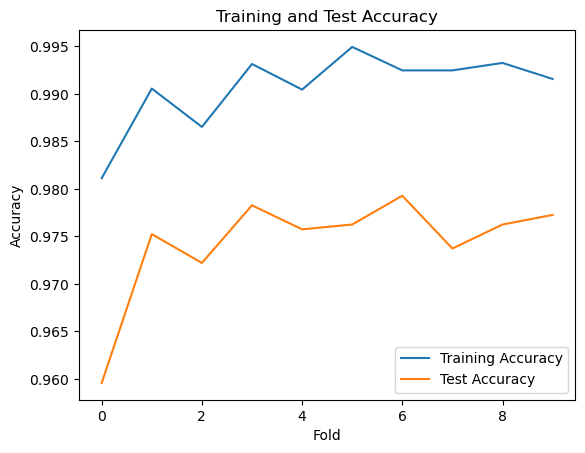

In [12]:
# Plot the training and test accuracies for each fold
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(test_accuracies, label='Test Accuracy')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('Training and Test Accuracy')
plt.legend()
plt.show()

In [13]:
# Calculate the mean accuracies for training, validation, and test sets
mean_train_accuracy = np.mean(train_accuracies)
mean_val_accuracy = np.mean(val_accuracies)
mean_test_accuracy = np.mean(test_accuracies)


print(f"Mean Test Accuracy: {mean_test_accuracy} ")
print(f"Mean Training Accuracy: {mean_train_accuracy} ")
print(f"Mean Validation Accuracy: {mean_val_accuracy} ")

Mean Test Accuracy: 0.9743809998035431 
Mean Training Accuracy: 0.9906554102897644 
Mean Validation Accuracy: 0.8128991603851319 


In [14]:
# Predict labels for the test set
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Generate classification report
report = classification_report(y_test, y_pred_classes, target_names=label_encoder.classes_)

# Print classification report
print(report)

62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step
              precision    recall  f1-score   support

           A       0.98      0.98      0.98       185
           N       0.98      0.99      0.98      1137
           O       0.97      0.96      0.97       627
           ~       0.93      0.90      0.92        30

    accuracy                           0.98      1979
   macro avg       0.97      0.96      0.96      1979
weighted avg       0.98      0.98      0.98      1979



62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


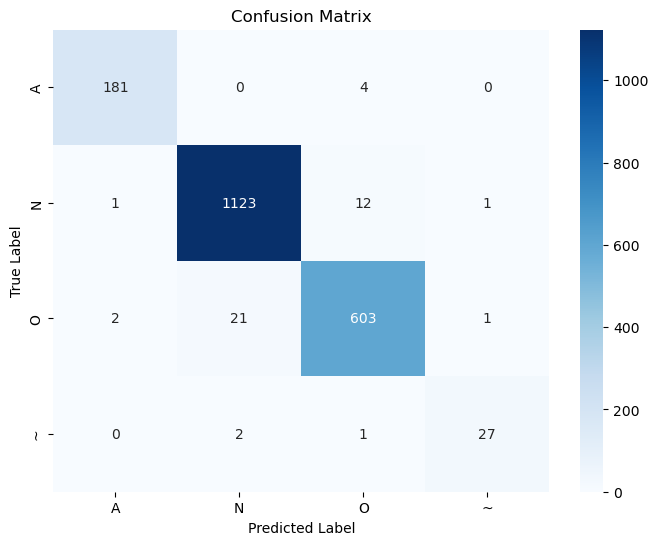

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
# Predict labels for the test set
y_pred_prob = model.predict(X_test)

# Get the predicted class for each sample
y_pred = np.argmax(y_pred_prob, axis=1)

# Compute confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [20]:
# Define the path to the folder
folder_path = "MODELS"

# Define the full path including the folder and filename
model_path = os.path.join(folder_path, "CNN_LTSM10.h5")

# Save the model
model.save(model_path)

In [21]:
from tensorflow.keras.models import load_model
loaded_model = load_model("MODElS/CNN_LTSM10.h5")

62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step


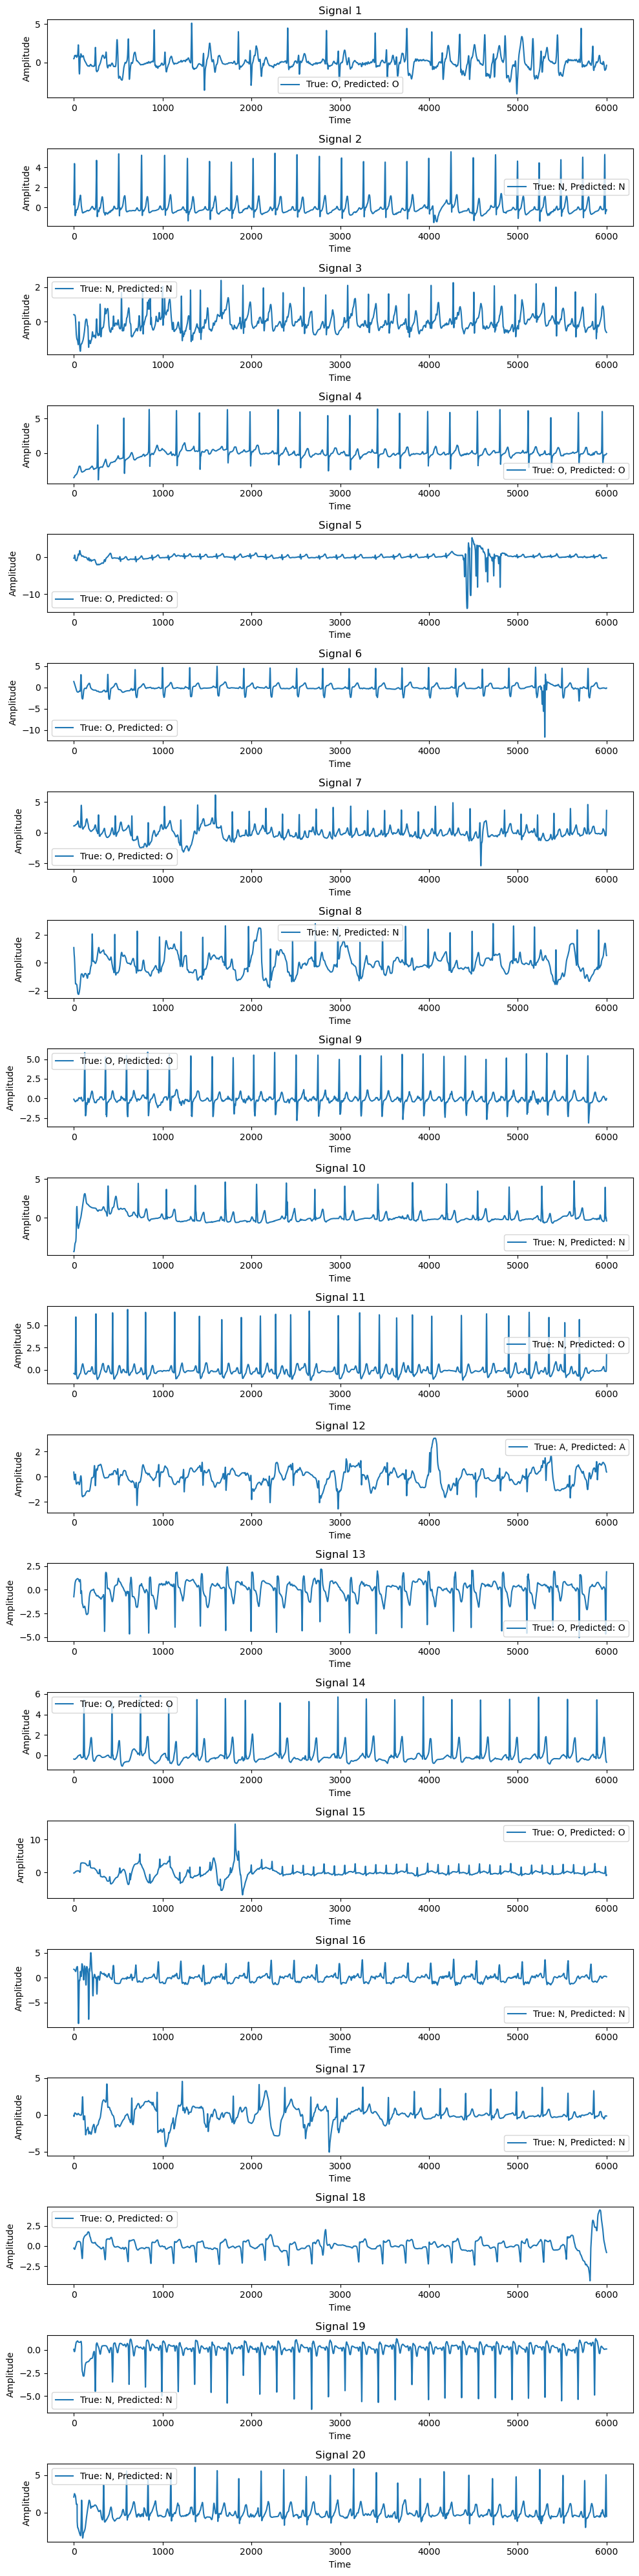

Correct Predictions: 1934
Incorrect Predictions: 45


In [22]:
# Plot sample signals with true and predicted labels, and display prediction accuracy
def plot_and_predict(X_test, y_test, model, label_encoder, num_samples=10):
    # Ensure num_samples does not exceed length of X_test
    num_samples = min(num_samples, len(X_test))

    # Predict the labels
    predictions = model.predict(X_test)
    predicted_labels = np.argmax(predictions, axis=1)

    # Count correct and incorrect predictions
    correct = np.sum(predicted_labels == y_test)
    incorrect = len(y_test) - correct

    # Reverse label mapping
    reverse_label_mapping = {index: label for index, label in enumerate(label_encoder.classes_)}

    # Start plotting
    fig, axes = plt.subplots(num_samples, 1, figsize=(10, num_samples * 2))
    if num_samples == 1:
        axes = [axes]  # Make it iterable

    for i, ax in enumerate(axes):
        signal = X_test[i].squeeze()  # Squeeze to convert (N, 1) to (N,)
        true_label = reverse_label_mapping[y_test[i]]
        predicted_label = reverse_label_mapping[predicted_labels[i]]
        ax.plot(signal, label=f'True: {true_label}, Predicted: {predicted_label}')
        ax.legend()
        ax.set_title(f'Signal {i+1}')
        ax.set_xlabel('Time')
        ax.set_ylabel('Amplitude')

    plt.tight_layout()
    plt.show()

    print(f"Correct Predictions: {correct}")
    print(f"Incorrect Predictions: {incorrect}")


plot_and_predict(X_test, y_test, loaded_model, label_encoder, num_samples=20)


In [19]:
# Define paths to save the datasets
train_data_path = 'X_train.npy'
test_data_path = 'X_test.npy'
train_labels_path = 'y_train.npy'
test_labels_path = 'y_test.npy'

# Save the datasets
np.save(train_data_path, X_train)
np.save(test_data_path, X_test)
np.save(train_labels_path, y_train)
np.save(test_labels_path, y_test)